In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


In [9]:
df = pd.read_csv("suicide-watch/suicide_watch_backup.csv")
df['clean_text'] = df['clean_text'].fillna('')
print(f"Dataset: {df.shape[0]} rows")

Dataset: 232074 rows


In [10]:
high_risk_keywords = [
    'kill myself', 'end my life', 'want to die', 'going to kill',
    'suicide', 'hang myself', 'shoot myself', 'jump off',
    'overdose', 'pills', 'no reason to live', 'better off dead'
]

mid_risk_keywords = [
    'hopeless', 'worthless', 'burden', 'empty', 'crying',
    'give up', 'tired of life', 'nothing matters', 'cutting',
    'hate myself', 'hate my life', 'feel like dying'
]

low_risk_keywords = [
    'depressed', 'sad', 'lonely', 'anxious', 'stressed',
    'overwhelmed', 'exhausted', 'struggling', 'hard to cope',
    'not okay', 'down', 'unhappy'
]

def classify_risk(text):
    text = str(text).lower()
    
    high_score = sum(1 for kw in high_risk_keywords if kw in text)
    mid_score = sum(1 for kw in mid_risk_keywords if kw in text)
    low_score = sum(1 for kw in low_risk_keywords if kw in text)
    
    if high_score >= 2 or (high_score >= 1 and mid_score >= 1):
        return 'strong'
    elif high_score >= 1:
        return 'high'
    elif mid_score >= 2:
        return 'mid'
    elif mid_score >= 1 or low_score >= 2:
        return 'low'
    else:
        return 'minimal'

df['risk_level'] = df['clean_text'].apply(classify_risk)
print("Risk Level Distribution:")
print(df['risk_level'].value_counts())

Risk Level Distribution:
risk_level
minimal    157264
high        29765
strong      25656
low         17236
mid          2153
Name: count, dtype: int64


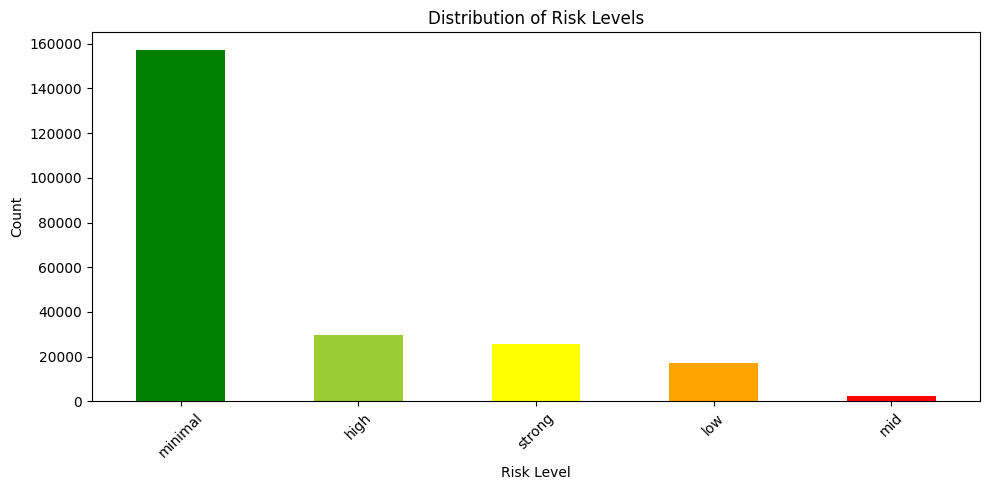

In [11]:
plt.figure(figsize=(10, 5))
df['risk_level'].value_counts().plot(kind='bar', color=['green', 'yellowgreen', 'yellow', 'orange', 'red'])
plt.title('Distribution of Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('risk_distribution.png', dpi=150)
plt.show()

In [12]:
risk_mapping = {'minimal': 0, 'low': 1, 'mid': 2, 'high': 3, 'strong': 4}
df['risk_label'] = df['risk_level'].map(risk_mapping)
print("Numeric Risk Labels:")
print(df[['risk_level', 'risk_label']].drop_duplicates().sort_values('risk_label'))

Numeric Risk Labels:
    risk_level  risk_label
1      minimal           0
3          low           1
260        mid           2
0         high           3
4       strong           4


In [13]:
X = df['clean_text']
y = df['risk_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 185659
Test samples: 46415


In [14]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', solver='lbfgs')
lr_model.fit(X_train_vec, y_train)
lr_pred = lr_model.predict(X_test_vec)

print("\n=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, lr_pred, target_names=['minimal', 'low', 'mid', 'high', 'strong']))

Training Logistic Regression...

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

     minimal       0.98      0.89      0.94     31453
         low       0.50      0.76      0.60      3447
         mid       0.26      0.62      0.37       431
        high       0.69      0.77      0.73      5953
      strong       0.79      0.74      0.76      5131

    accuracy                           0.85     46415
   macro avg       0.64      0.76      0.68     46415
weighted avg       0.88      0.85      0.86     46415



In [15]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_vec, y_train)
rf_pred = rf_model.predict(X_test_vec)

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, rf_pred, target_names=['minimal', 'low', 'mid', 'high', 'strong']))

Training Random Forest...

=== RANDOM FOREST ===
              precision    recall  f1-score   support

     minimal       0.88      0.99      0.93     31453
         low       0.66      0.17      0.27      3447
         mid       1.00      0.00      0.01       431
        high       0.78      0.60      0.68      5953
      strong       0.73      0.74      0.73      5131

    accuracy                           0.84     46415
   macro avg       0.81      0.50      0.52     46415
weighted avg       0.83      0.84      0.82     46415



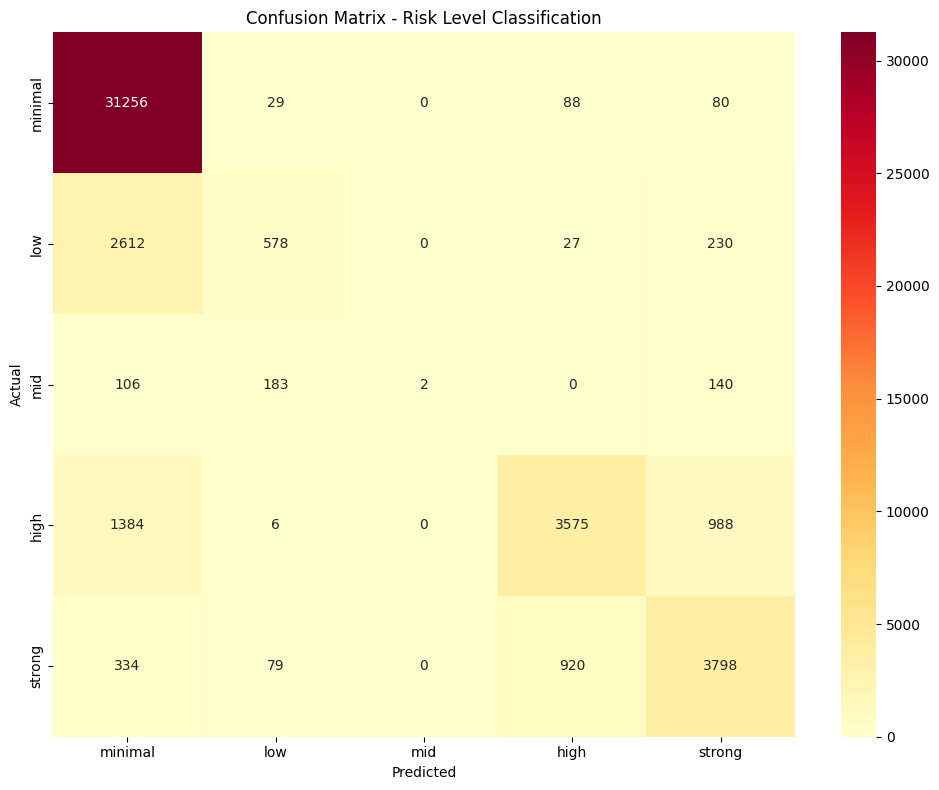

In [16]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['minimal', 'low', 'mid', 'high', 'strong'],
            yticklabels=['minimal', 'low', 'mid', 'high', 'strong'])
plt.title('Confusion Matrix - Risk Level Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('risk_confusion_matrix.png', dpi=150)
plt.show()

In [17]:
test_texts = [
    "Today was a good day at work!",
    "Feeling a bit down lately, not sure why",
    "Been struggling with depression and feeling worthless",
    "I think about ending my life sometimes",
    "I want to kill myself, I have a plan"
]

test_vec = vectorizer.transform(test_texts)
predictions = rf_model.predict(test_vec)

reverse_mapping = {v: k for k, v in risk_mapping.items()}

print("=== SAMPLE PREDICTIONS ===")
for text, pred in zip(test_texts, predictions):
    print(f"Text: '{text[:50]}...'")
    print(f"Risk Level: {reverse_mapping[pred]}")
    print("-" * 50)

=== SAMPLE PREDICTIONS ===
Text: 'Today was a good day at work!...'
Risk Level: minimal
--------------------------------------------------
Text: 'Feeling a bit down lately, not sure why...'
Risk Level: minimal
--------------------------------------------------
Text: 'Been struggling with depression and feeling worthl...'
Risk Level: low
--------------------------------------------------
Text: 'I think about ending my life sometimes...'
Risk Level: minimal
--------------------------------------------------
Text: 'I want to kill myself, I have a plan...'
Risk Level: high
--------------------------------------------------


In [18]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/risk_level_classifier.pkl")
joblib.dump(vectorizer, "models/risk_vectorizer.pkl")

df.to_csv("suicide-watch/suicide_watch_with_risk_levels.csv", index=False)

print("Models and dataset saved!")
print("  - models/risk_level_classifier.pkl")
print("  - models/risk_vectorizer.pkl")
print("  - suicide-watch/suicide_watch_with_risk_levels.csv")

Models and dataset saved!
  - models/risk_level_classifier.pkl
  - models/risk_vectorizer.pkl
  - suicide-watch/suicide_watch_with_risk_levels.csv


In [ ]:
print("\n" + "="*60)
print("RISK LEVEL CLASSIFICATION SUMMARY")
print("="*60)
print("""
Risk Levels:
  0 - MINIMAL: No risk indicators
  1 - LOW: Mild distress (sad, stressed, overwhelmed)
  2 - MID: Moderate risk (hopeless, worthlessness, self-harm thoughts)
  3 - HIGH: High risk (explicit suicide mentions)
  4 - STRONG: Critical (active plans, multiple high-risk indicators)

Best Model: Random Forest
Features: TF-IDF with bigrams
Dataset saved with new risk_level column
""")


RISK LEVEL CLASSIFICATION SUMMARY

Risk Levels:
  0 - MINIMAL: No risk indicators
  1 - LOW: Mild distress (sad, stressed, overwhelmed)
  2 - MID: Moderate risk (hopeless, worthlessness, self-harm thoughts)
  3 - HIGH: High risk (explicit suicide mentions)
  4 - STRONG: Critical (active plans, multiple high-risk indicators)

Best Model: Random Forest
Features: TF-IDF with bigrams
Dataset saved with new risk_level column



: 